# MobileViT-XXS: ablação controlada do agrupamento estrutural

Este notebook compara `g8_4_4` com alternativas sob o mesmo checkpoint, conjunto de calibração, quantizador e conjunto de validação.

A matriz experimental mede:

1. contribuição isolada dos blocos 1, 2, 3, 5 e 7;
2. efeito de remover um dos blocos de `g8_4_4`;
3. efeito da intensidade do agrupamento;
4. efeito de acrescentar os blocos 3 ou 7;
5. custo estrutural em ramificações, tamanho e operadores.

Todas as variantes são comparadas na validação. O teste é executado uma única vez para a configuração escolhida pela regra declarada no notebook. Os resultados são gravados somente em `results/` nesta pasta.

In [1]:
import copy
import gc
import csv
import json
import os
import random
from pathlib import Path

import flatbuffers
import litert_torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from ai_edge_litert import schema_py_generated as schema
from ai_edge_litert.interpreter import Interpreter, OpResolverType
from ai_edge_quantizer import quantizer, recipe
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from transformers import MobileViTForImageClassification

SEED = 42


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True


set_seed(SEED)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


## Configuração experimental

In [2]:
PATH = Path("/home/jovyan/work/UFSC/butterflies_austria/Dataset_train_test_split/butterflies-austria")
EXPERIMENT_FOLDER = "artigo_experimentos_MobileVIT_v4"
NOTEBOOK_NAME = "artigo_experimentos_MobileVIT_v4.ipynb"
candidates = [
    candidate
    for ancestor in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    for candidate in (
        ancestor,
        ancestor / EXPERIMENT_FOLDER,
        ancestor / "artigo_experimentos" / EXPERIMENT_FOLDER,
        ancestor / "butterflies_austria_edge_vision" / "artigo_experimentos" / EXPERIMENT_FOLDER,
    )
]
NOTEBOOK_DIR = next(
    (candidate for candidate in candidates if (candidate / NOTEBOOK_NAME).is_file()),
    None,
)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError(NOTEBOOK_NAME)

CHECKPOINT_CANDIDATES = [
    NOTEBOOK_DIR / "best_mobilevit_xx_small_v0.pt",
    NOTEBOOK_DIR.parent / "artigo_experimentos_MobileVIT_v3_block7" / "best_mobilevit_xx_small_v0.pt",
    NOTEBOOK_DIR.parent / "artigo_experimentos_MobileVIT_v2_esp_verify" / "best_mobilevit_xx_small_v0.pt",
]
CHECKPOINT_PATH = next((path for path in CHECKPOINT_CANDIDATES if path.is_file()), None)
if CHECKPOINT_PATH is None:
    raise FileNotFoundError("best_mobilevit_xx_small_v0.pt")

EXPERIMENTS = {
    "b1_g8": {1: 8},
    "b2_g4": {2: 4},
    "b3_g4": {3: 4},
    "b5_g4": {5: 4},
    "b7_g8": {7: 8},
    "b1_g8_b2_g4": {1: 8, 2: 4},
    "b1_g8_b5_g4": {1: 8, 5: 4},
    "b2_g4_b5_g4": {2: 4, 5: 4},
    "g4_4_4": {1: 4, 2: 4, 5: 4},
    "g8_2_4": {1: 8, 2: 2, 5: 4},
    "g8_4_4": {1: 8, 2: 4, 5: 4},
    "g8_8_4": {1: 8, 2: 8, 5: 4},
    "g8_4_2": {1: 8, 2: 4, 5: 2},
    "g8_4_8": {1: 8, 2: 4, 5: 8},
    "g8_8_8": {1: 8, 2: 8, 5: 8},
    "g8_4_4_b3_g4": {1: 8, 2: 4, 3: 4, 5: 4},
    "g8_4_4_b7_g8": {1: 8, 2: 4, 5: 4, 7: 8},
}
TARGET_EXPERIMENT = "g8_4_4"
REBUILD_ARTIFACTS = False

RESULTS_ROOT = NOTEBOOK_DIR / "results"
SHARED_DIR = RESULTS_ROOT / "shared"
VARIANTS_DIR = RESULTS_ROOT / "variants"
FIGURES_DIR = RESULTS_ROOT / "figures"
OUTPUT_DIR = SHARED_DIR
for directory in (SHARED_DIR, VARIANTS_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 64
IMG_SIZE = 256
RESIZE_SIZE = 288
CALIBRATION_SAMPLES_PER_CLASS = 50
MIN_GROUPED_INT8_ACCURACY = 0.70
MIN_ACCURACY_GAIN = 0.50
MIN_FP32_TOP1_AGREEMENT = 0.998
MAX_FP32_LOGIT_ERROR = 0.05
MAX_RESOLVER_ACCURACY_DELTA = 0.01
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with (RESULTS_ROOT / "ablation_configuration.json").open("w") as file:
    json.dump({
        "checkpoint": str(CHECKPOINT_PATH),
        "experiments": EXPERIMENTS,
        "target_experiment": TARGET_EXPERIMENT,
        "seed": SEED,
        "calibration_samples_per_class": CALIBRATION_SAMPLES_PER_CLASS,
        "selection_split": "validation",
    }, file, indent=2)

print(f"Device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Variants: {len(EXPERIMENTS)}")
print(f"Results: {RESULTS_ROOT}")

Device: cuda
Checkpoint: /home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/artigo_experimentos_MobileVIT_v3_block7/best_mobilevit_xx_small_v0.pt
Variants: 17
Results: /home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/artigo_experimentos_MobileVIT_v4/results


## Dataset e calibração estratificada

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize(RESIZE_SIZE),
    transforms.RandomCrop(IMG_SIZE),
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.RandomHorizontalFlip(p=0.1),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Lambda(lambda image: image[[2, 1, 0]]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize(RESIZE_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.ToTensor(),
    transforms.Lambda(lambda image: image[[2, 1, 0]]),
])

In [4]:
train_dir = PATH / "train"
val_dir = PATH / "val"
test_dir = PATH / "test"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
calibration_source = datasets.ImageFolder(train_dir, transform=val_test_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

if calibration_source.class_to_idx != class_to_idx:
    raise ValueError("Training and calibration classes are not aligned")

if val_dataset.class_to_idx != class_to_idx:
    raise ValueError("Training and validation classes are not aligned")

if test_dataset.class_to_idx != class_to_idx:
    raise ValueError("Training and test classes are not aligned")

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": 4,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": True,
}

val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

print(f"Classes: {len(class_names)}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 20
Train: 5183 | Val: 648 | Test: 648


In [5]:
train_targets = np.asarray(train_dataset.targets)
train_counts = np.bincount(train_targets, minlength=len(class_names))

print("Training distribution:")
for name, count in zip(class_names, train_counts):
    print(f"  {name:30s}: {count}")

Training distribution:
  Aglais_Urticae                : 215
  Anthocharis_Cardamines        : 361
  Apatura_Iris                  : 279
  Argynnis_Paphia               : 316
  Colias_Myrmidone              : 227
  Gonepteryx_Rhamni             : 186
  Inachis_Io                    : 218
  Iphiclides_Podalirius         : 238
  Lycaena_Virgaureae            : 137
  Lycaenidae                    : 332
  Maniola_Jurtina               : 326
  Melanargia_Galathea           : 328
  Nymphalis_Antiopa             : 128
  Papilio_Machaon               : 194
  Parnassius_Apollo             : 247
  Pieris_Rapae                  : 294
  Polygonia_C-album             : 317
  Vanessa_Atalanta              : 379
  Vanessa_Cardui                : 266
  Zerynthia_Polyxena            : 195


In [6]:
def select_stratified_calibration_indices(targets, samples_per_class, seed):
    generator = torch.Generator().manual_seed(seed)
    selected_indices = []

    for label in range(len(class_names)):
        class_indices = np.flatnonzero(targets == label)

        if len(class_indices) < samples_per_class:
            raise ValueError(f"Class {class_names[label]} has insufficient calibration samples")

        permutation = torch.randperm(len(class_indices), generator=generator)[:samples_per_class]
        selected_indices.extend(class_indices[permutation.numpy()].tolist())

    return sorted(selected_indices)


calibration_indices = select_stratified_calibration_indices(
    np.asarray(calibration_source.targets),
    CALIBRATION_SAMPLES_PER_CLASS,
    SEED,
)
calibration_dataset = Subset(calibration_source, calibration_indices)
calibration_loader = DataLoader(calibration_dataset, shuffle=False, **loader_options)

with (OUTPUT_DIR / "calibration_manifest.csv").open("w", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=["path", "label", "class_name"])
    writer.writeheader()

    for index in calibration_indices:
        path, label = calibration_source.samples[index]
        writer.writerow({"path": path, "label": label, "class_name": class_names[label]})

calibration_counts = np.bincount(
    np.asarray(calibration_source.targets)[calibration_indices],
    minlength=len(class_names),
)

if not np.all(calibration_counts == CALIBRATION_SAMPLES_PER_CLASS):
    raise RuntimeError("Calibration dataset is not balanced")

print(f"Calibration samples: {len(calibration_dataset)}")
print(f"Samples per class: {calibration_counts.tolist()}")

Calibration samples: 1000
Samples per class: [50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50]


## Modelo e checkpoint

In [7]:
MODEL_NAME = "apple/mobilevit-xx-small"

hf_model = MobileViTForImageClassification.from_pretrained(
    MODEL_NAME,
    cache_dir=str(NOTEBOOK_DIR / "hf_cache"),
    num_labels=len(class_names),
    id2label={index: name for index, name in enumerate(class_names)},
    label2id={name: index for index, name in enumerate(class_names)},
    classifier_dropout_prob=0.3,
    ignore_mismatched_sizes=True,
)


class MobileViTClassifier(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, inputs):
        return self.model(pixel_values=inputs, return_dict=False)[0]


model = MobileViTClassifier(hf_model).to(DEVICE)

[transformers] You passed `num_labels=20` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/347 [00:00<?, ?it/s]

[transformers] MobileViTForImageClassification LOAD REPORT from: apple/mobilevit-xx-small
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([20])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 320]) vs model:torch.Size([20, 320])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [8]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint, strict=True)
model.eval()

total_params = sum(parameter.numel() for parameter in model.parameters())
print(f"Checkpoint loaded: {CHECKPOINT_PATH.name}")
print(f"Total parameters: {total_params:,}")

Checkpoint loaded: best_mobilevit_xx_small_v0.pt
Total parameters: 957,444


## Diagnóstico compartilhado das ativações

In [9]:
def find_inverted_residuals(root):
    blocks = []

    for parent_name, parent in root.named_modules():
        for child_name, child in parent.named_children():
            required_layers = ("expand_1x1", "conv_3x3", "reduce_1x1")

            if all(hasattr(child, layer_name) for layer_name in required_layers):
                full_name = f"{parent_name}.{child_name}" if parent_name else child_name
                blocks.append({
                    "parent": parent,
                    "child_name": child_name,
                    "name": full_name,
                    "module": child,
                })

    if len(blocks) != 7:
        raise RuntimeError(f"Expected 7 inverted residual blocks, found {len(blocks)}")

    return blocks


def collect_channel_statistics(current_model, blocks, data_loader, device):
    accumulators = {}
    handles = []

    def create_hook(block_index):
        def hook(_, __, output):
            values = output.detach()
            channel_count = values.shape[1]
            current = accumulators.get(block_index)

            if current is None:
                current = {
                    "minimum": torch.full((channel_count,), float("inf")),
                    "maximum": torch.full((channel_count,), float("-inf")),
                    "sum_squares": torch.zeros(channel_count, dtype=torch.float64),
                    "element_count": 0,
                }
                accumulators[block_index] = current

            dimensions = (0, 2, 3)
            current["minimum"] = torch.minimum(
                current["minimum"],
                values.amin(dim=dimensions).float().cpu(),
            )
            current["maximum"] = torch.maximum(
                current["maximum"],
                values.amax(dim=dimensions).float().cpu(),
            )
            current["sum_squares"] += values.float().square().sum(dim=dimensions).double().cpu()
            current["element_count"] += values.shape[0] * values.shape[2] * values.shape[3]

        return hook

    for block_index, block_info in enumerate(blocks, start=1):
        handles.append(block_info["module"].expand_1x1.register_forward_hook(create_hook(block_index)))

    current_model.eval()

    try:
        with torch.no_grad():
            for images, _ in data_loader:
                current_model(images.to(device, non_blocking=True))
    finally:
        for handle in handles:
            handle.remove()

    records = []
    scales_by_block = {}

    for block_index, block_info in enumerate(blocks, start=1):
        current = accumulators[block_index]
        minimum = current["minimum"]
        maximum = current["maximum"]
        channel_range = maximum - minimum
        channel_scale = torch.clamp(channel_range / 255.0, min=torch.finfo(torch.float32).eps)
        tensor_scale = max(
            float((maximum.max() - minimum.min()) / 255.0),
            torch.finfo(torch.float32).eps,
        )
        rms = torch.sqrt(current["sum_squares"] / current["element_count"]).float()
        scales_by_block[block_index] = channel_scale

        for channel in range(len(channel_scale)):
            approximate_codes = min(256, int(torch.floor(channel_range[channel] / tensor_scale).item()) + 1)
            records.append({
                "block": block_index,
                "block_name": block_info["name"],
                "channel": channel,
                "minimum": float(minimum[channel]),
                "maximum": float(maximum[channel]),
                "rms": float(rms[channel]),
                "channel_scale": float(channel_scale[channel]),
                "tensor_scale": tensor_scale,
                "rms_over_tensor_scale": float(rms[channel] / tensor_scale),
                "approximate_int8_codes": approximate_codes,
            })

    return records, scales_by_block


def write_csv(path, records):
    if not records:
        raise ValueError(f"No records to write: {path}")

    with path.open("w", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=records[0].keys())
        writer.writeheader()
        writer.writerows(records)

In [10]:
inverted_residuals = find_inverted_residuals(model)
channel_records, scales_by_block = collect_channel_statistics(
    model,
    inverted_residuals,
    calibration_loader,
    DEVICE,
)
write_csv(OUTPUT_DIR / "channel_statistics.csv", channel_records)

In [11]:
def create_groups(group_counts, scales_by_block):
    groups_by_block = {}
    group_records = []

    for block_index, group_count in group_counts.items():
        ordered_channels = torch.argsort(scales_by_block[block_index])
        groups = [group.tolist() for group in torch.tensor_split(ordered_channels, group_count)]
        groups_by_block[block_index] = groups

        for group_index, channels in enumerate(groups):
            group_scales = scales_by_block[block_index][channels]
            group_records.append({
                "block": block_index,
                "group": group_index,
                "channels": json.dumps(channels),
                "channel_count": len(channels),
                "minimum_scale": float(group_scales.min()),
                "maximum_scale": float(group_scales.max()),
                "scale_ratio": float(group_scales.max() / group_scales.min()),
            })

    return groups_by_block, group_records


for block_index, scale_values in scales_by_block.items():
    ratio = float(scale_values.max() / scale_values.min())
    channel_codes = [
        row["approximate_int8_codes"]
        for row in channel_records
        if row["block"] == block_index
    ]
    print(
        f"Block {block_index}: channels={len(scale_values)} "
        f"scale_ratio={ratio:.2f}x median_codes={np.median(channel_codes):.1f}"
    )

Block 1: channels=32 scale_ratio=327.61x median_codes=8.0
Block 2: channels=32 scale_ratio=874.36x median_codes=10.0
Block 3: channels=48 scale_ratio=156.28x median_codes=6.0
Block 4: channels=48 scale_ratio=94.35x median_codes=37.5
Block 5: channels=48 scale_ratio=318.00x median_codes=8.5
Block 6: channels=96 scale_ratio=107.49x median_codes=49.5
Block 7: channels=128 scale_ratio=487.58x median_codes=47.0


## Transformação estrutural e equivalência FP32

In [12]:
class SlicedConvLayer(nn.Module):
    def __init__(self, source_layer, channels, depthwise):
        super().__init__()
        source_conv = source_layer.convolution
        channel_indices = torch.as_tensor(channels, dtype=torch.long)

        if depthwise:
            in_channels = len(channels)
            out_channels = len(channels)
            groups = len(channels)
            weight = source_conv.weight.detach().index_select(0, channel_indices)
            bias = None if source_conv.bias is None else source_conv.bias.detach().index_select(0, channel_indices)
        else:
            in_channels = source_conv.in_channels
            out_channels = len(channels)
            groups = source_conv.groups
            weight = source_conv.weight.detach().index_select(0, channel_indices)
            bias = None if source_conv.bias is None else source_conv.bias.detach().index_select(0, channel_indices)

        self.convolution = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=source_conv.kernel_size,
            stride=source_conv.stride,
            padding=source_conv.padding,
            dilation=source_conv.dilation,
            groups=groups,
            bias=bias is not None,
            padding_mode=source_conv.padding_mode,
        )

        with torch.no_grad():
            self.convolution.weight.copy_(weight)

            if bias is not None:
                self.convolution.bias.copy_(bias)

        self.normalization = self.create_batch_norm(source_layer.normalization, channel_indices)
        self.activation = copy.deepcopy(source_layer.activation)

    @staticmethod
    def create_batch_norm(source, channel_indices):
        if source is None:
            return None

        if not isinstance(source, nn.BatchNorm2d):
            raise TypeError(f"Unsupported normalization: {type(source).__name__}")

        result = nn.BatchNorm2d(
            len(channel_indices),
            eps=source.eps,
            momentum=source.momentum,
            affine=source.affine,
            track_running_stats=source.track_running_stats,
        )

        with torch.no_grad():
            if source.affine:
                result.weight.copy_(source.weight.detach().index_select(0, channel_indices))
                result.bias.copy_(source.bias.detach().index_select(0, channel_indices))

            if source.track_running_stats:
                result.running_mean.copy_(source.running_mean.detach().index_select(0, channel_indices))
                result.running_var.copy_(source.running_var.detach().index_select(0, channel_indices))
                result.num_batches_tracked.copy_(source.num_batches_tracked.detach())

        return result

    def forward(self, inputs):
        outputs = self.convolution(inputs)

        if self.normalization is not None:
            outputs = self.normalization(outputs)

        if self.activation is not None:
            outputs = self.activation(outputs)

        return outputs


def fold_conv_batch_norm(source_layer):
    convolution = source_layer.convolution
    normalization = source_layer.normalization
    weight = convolution.weight.detach().clone()
    bias = (
        convolution.bias.detach().clone()
        if convolution.bias is not None
        else torch.zeros(convolution.out_channels, dtype=weight.dtype, device=weight.device)
    )

    if normalization is None:
        return weight, bias

    if not isinstance(normalization, nn.BatchNorm2d):
        raise TypeError(f"Unsupported normalization: {type(normalization).__name__}")

    factor = normalization.weight.detach() / torch.sqrt(normalization.running_var.detach() + normalization.eps)
    folded_weight = weight * factor[:, None, None, None]
    folded_bias = (bias - normalization.running_mean.detach()) * factor + normalization.bias.detach()
    return folded_weight, folded_bias


class GroupedBranch(nn.Module):
    def __init__(self, source_block, channels, group_count, folded_weight, folded_bias):
        super().__init__()
        channel_indices = torch.as_tensor(channels, dtype=torch.long)
        self.expand = SlicedConvLayer(source_block.expand_1x1, channels, depthwise=False)
        self.depthwise = SlicedConvLayer(source_block.conv_3x3, channels, depthwise=True)
        source_reduce = source_block.reduce_1x1.convolution
        self.reduce = nn.Conv2d(
            in_channels=len(channels),
            out_channels=source_reduce.out_channels,
            kernel_size=source_reduce.kernel_size,
            stride=source_reduce.stride,
            padding=source_reduce.padding,
            dilation=source_reduce.dilation,
            groups=source_reduce.groups,
            bias=True,
            padding_mode=source_reduce.padding_mode,
        )

        with torch.no_grad():
            self.reduce.weight.copy_(folded_weight.index_select(1, channel_indices))
            self.reduce.bias.copy_(folded_bias / group_count)

    def forward(self, inputs):
        outputs = self.expand(inputs)
        outputs = self.depthwise(outputs)
        return self.reduce(outputs)


class GroupedInvertedResidual(nn.Module):
    def __init__(self, source_block, groups):
        super().__init__()
        folded_weight, folded_bias = fold_conv_batch_norm(source_block.reduce_1x1)
        self.branches = nn.ModuleList([
            GroupedBranch(source_block, channels, len(groups), folded_weight, folded_bias)
            for channels in groups
        ])
        self.use_residual = source_block.use_residual

    def forward(self, inputs):
        outputs = self.branches[0](inputs)

        for branch in self.branches[1:]:
            outputs = outputs + branch(inputs)

        return inputs + outputs if self.use_residual else outputs


def build_grouped_model(reference_model, groups):
    grouped_model = copy.deepcopy(reference_model).cpu().eval()
    grouped_blocks = find_inverted_residuals(grouped_model)

    for block_index, block_groups in groups.items():
        block_info = grouped_blocks[block_index - 1]
        grouped_block = GroupedInvertedResidual(block_info["module"], block_groups)
        setattr(block_info["parent"], block_info["child_name"], grouped_block)

    return grouped_model

In [13]:
def collect_torch_outputs(current_model, data_loader, device):
    outputs = []
    labels = []
    current_model = current_model.to(device).eval()

    with torch.no_grad():
        for images, targets in data_loader:
            outputs.append(current_model(images.to(device, non_blocking=True)).cpu())
            labels.append(targets.cpu())

    current_model.cpu()
    return torch.cat(outputs), torch.cat(labels)


reference_model = copy.deepcopy(model).cpu().eval()
reference_outputs, validation_labels = collect_torch_outputs(reference_model, val_loader, DEVICE)
reference_predictions = reference_outputs.argmax(dim=1)
reference_accuracy = float((reference_predictions == validation_labels).float().mean())
FP32_MAX_ACCURACY_DELTA = 1.0 / len(validation_labels)


def evaluate_fp32_equivalence(candidate_model):
    candidate_outputs, candidate_labels = collect_torch_outputs(candidate_model, val_loader, DEVICE)
    if not torch.equal(validation_labels, candidate_labels):
        raise RuntimeError("Validation labels changed during equivalence evaluation")

    candidate_predictions = candidate_outputs.argmax(dim=1)
    candidate_accuracy = float((candidate_predictions == validation_labels).float().mean())
    result = {
        "reference_accuracy": reference_accuracy,
        "grouped_accuracy": candidate_accuracy,
        "accuracy_delta": abs(reference_accuracy - candidate_accuracy),
        "top1_agreement": float((reference_predictions == candidate_predictions).float().mean()),
        "maximum_logit_error": float((reference_outputs - candidate_outputs).abs().max()),
        "mean_logit_error": float((reference_outputs - candidate_outputs).abs().mean()),
        "logits_cosine": float(F.cosine_similarity(reference_outputs.flatten(), candidate_outputs.flatten(), dim=0)),
    }
    result["passed"] = (
        result["top1_agreement"] >= MIN_FP32_TOP1_AGREEMENT
        and result["maximum_logit_error"] <= MAX_FP32_LOGIT_ERROR
    )
    return result

## Exportação, quantização e inspeção LiteRT

In [14]:
ESP32_INPUT_SHAPE = (1, 3, 256, 256)
ESP32_OUTPUT_SHAPE = (1, len(class_names))
ESP32_SUPPORTED_OP_VERSIONS = {
    "ADD": frozenset({1}),
    "AVERAGE_POOL_2D": frozenset({1}),
    "CONCATENATION": frozenset({1}),
    "CONV_2D": frozenset({1}),
    "DEPTHWISE_CONV_2D": frozenset({1}),
    "FULLY_CONNECTED": frozenset({5}),
    "LOGISTIC": frozenset({1}),
    "MEAN": frozenset({1}),
    "MUL": frozenset({1}),
    "PAD": frozenset({1}),
    "QUANTIZE": frozenset({1}),
    "RESHAPE": frozenset({1}),
    "RSQRT": frozenset({1}),
    "SOFTMAX": frozenset({1}),
    "SQUARED_DIFFERENCE": frozenset({1}),
    "SUB": frozenset({1}),
    "TRANSPOSE": frozenset({1}),
}
ESP32_SUPPORTED_OPS = frozenset(ESP32_SUPPORTED_OP_VERSIONS)


class MobileViTFixedAvgPool(nn.Module):
    def __init__(self, source_model):
        super().__init__()
        classifier_model = source_model.model
        self.mobilevit = classifier_model.mobilevit
        self.dropout = classifier_model.dropout
        self.classifier = classifier_model.classifier

    def forward(self, inputs):
        features = self.mobilevit.conv_stem(inputs)
        features = self.mobilevit.encoder(
            features,
            output_hidden_states=False,
            return_dict=False,
        )[0]
        if not self.mobilevit.expand_output:
            raise RuntimeError("MobileViT sem expansão final não suportada")

        features = self.mobilevit.conv_1x1_exp(features)
        spatial_shape = tuple(features.shape[-2:])
        if spatial_shape != (8, 8):
            raise ValueError(f"Feature map esperado: 8x8; recebido: {spatial_shape}")

        features = F.avg_pool2d(features, kernel_size=(8, 8), stride=1)
        features = torch.flatten(features, 1)
        features = self.dropout(features)
        return self.classifier(features)


def mobilevit_export_adapter(source_model):
    candidate = copy.deepcopy(source_model).cpu().eval()
    return MobileViTFixedAvgPool(candidate).eval()


def prepare_export_model(source_model, inputs):
    baseline = copy.deepcopy(source_model).cpu().eval()
    candidate = mobilevit_export_adapter(source_model)

    with torch.no_grad():
        expected = baseline(inputs[0])
        actual = candidate(inputs[0])

    torch.testing.assert_close(actual, expected, rtol=1e-5, atol=1e-6)
    max_error = float(torch.max(torch.abs(expected - actual)))
    print(f"Erro absoluto máximo do adaptador: {max_error:.10f}")
    return candidate


def inline_external_buffers(source_path, target_path):
    content = source_path.read_bytes()
    model = schema.Model.GetRootAsModel(content, 0)
    model_object = schema.ModelT.InitFromObj(model)
    converted = 0

    for index, target_buffer in enumerate(model_object.buffers):
        source_buffer = model.Buffers(index)
        offset = source_buffer.Offset()
        size = source_buffer.Size()
        if not offset or not size:
            continue

        end = offset + size
        if end > len(content):
            raise ValueError(f"Buffer {index} fora do arquivo: {offset}:{end}")

        target_buffer.data = bytearray(content[offset:end])
        target_buffer.offset = 0
        target_buffer.size = 0
        converted += 1

    builder = flatbuffers.Builder(len(content))
    model_offset = model_object.Pack(builder)
    builder.Finish(model_offset, file_identifier=b"TFL3")
    target_path.write_bytes(builder.Output())
    return converted


def export_with_inline_buffers(exporter, output_path):
    external_path = output_path.with_name(f"{output_path.stem}_external{output_path.suffix}")
    inline_path = output_path.with_name(f".{output_path.name}.tmp")
    external_path.unlink(missing_ok=True)
    inline_path.unlink(missing_ok=True)

    try:
        exporter(external_path)
        converted = inline_external_buffers(external_path, inline_path)
        os.replace(inline_path, output_path)
    finally:
        external_path.unlink(missing_ok=True)
        inline_path.unlink(missing_ok=True)

    print(f"{output_path.name}: {converted} buffers incorporados")


def export_fp32(current_model, output_path, sample_inputs):
    with torch.no_grad():
        edge_model = litert_torch.convert(current_model, sample_inputs)

    export_with_inline_buffers(
        lambda external_path: edge_model.export(str(external_path)),
        output_path,
    )
    print(f"Exported: {output_path} ({output_path.stat().st_size / 1024 / 1024:.2f} MB)")




In [15]:
def create_calibration_data(model_path, dataset):
    interpreter = Interpreter(model_path=str(model_path))
    signatures = interpreter.get_signature_list()

    if len(signatures) != 1:
        raise ValueError(f"Expected one signature, found: {list(signatures)}")

    signature_name, signature = next(iter(signatures.items()))
    input_names = signature["inputs"]

    if len(input_names) != 1:
        raise ValueError(f"Expected one input, found: {input_names}")

    input_name = input_names[0]
    samples = []

    for image, _ in dataset:
        samples.append({input_name: image.unsqueeze(0).numpy().astype(np.float32)})

    return {signature_name: samples}

In [16]:
def quantize_static(fp32_path, output_path, dataset):
    calibration_data = create_calibration_data(fp32_path, dataset)
    current_quantizer = quantizer.Quantizer(str(fp32_path))
    current_quantizer.load_quantization_recipe(recipe.static_wi8_ai8())
    calibration_result = current_quantizer.calibrate(calibration_data)
    result = current_quantizer.quantize(calibration_result)

    export_with_inline_buffers(
        lambda external_path: result.export_model(str(external_path), overwrite=True),
        output_path,
    )
    print(f"Quantized: {output_path} ({output_path.stat().st_size / 1024 / 1024:.2f} MB)")

In [17]:
def create_interpreter(model_path, resolver_type):
    interpreter = Interpreter(
        model_path=str(model_path),
        experimental_op_resolver_type=resolver_type,
    )
    interpreter.allocate_tensors()
    return interpreter


def external_buffer_indices(model):
    return [
        index
        for index in range(model.BuffersLength())
        if model.Buffers(index).Offset() or model.Buffers(index).Size()
    ]


def operator_versions(model):
    names = {
        value: name
        for name, value in vars(schema.BuiltinOperator).items()
        if name.isupper() and isinstance(value, int)
    }
    return [
        (
            names.get(
                model.OperatorCodes(index).BuiltinCode(),
                str(model.OperatorCodes(index).BuiltinCode()),
            ),
            model.OperatorCodes(index).Version(),
        )
        for index in range(model.OperatorCodesLength())
    ]


def inspect_tflite(model_path):
    content = model_path.read_bytes()
    if len(content) < 8 or content[4:8] != b"TFL3":
        raise RuntimeError(f"{model_path.name}: identificador TFL3 inválido")

    model = schema.Model.GetRootAsModel(content, 0)
    if model.Version() != 3:
        raise RuntimeError(f"{model_path.name}: schema {model.Version()} não suportado")

    external_buffers = external_buffer_indices(model)
    if external_buffers:
        raise RuntimeError(f"{model_path.name}: buffers externos {external_buffers}")

    interpreter = create_interpreter(
        model_path,
        OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES,
    )
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    operators = [operation["op_name"] for operation in interpreter._get_ops_details()]
    versions = operator_versions(model)
    input_shape = tuple(int(value) for value in input_detail["shape"])
    output_shape = tuple(int(value) for value in output_detail["shape"])

    if input_shape != ESP32_INPUT_SHAPE:
        raise RuntimeError(f"{model_path.name}: entrada {input_shape}, esperado {ESP32_INPUT_SHAPE}")
    if output_shape != ESP32_OUTPUT_SHAPE:
        raise RuntimeError(f"{model_path.name}: saída {output_shape}, esperado {ESP32_OUTPUT_SHAPE}")
    if "SUM" in operators:
        raise RuntimeError(f"{model_path.name}: operador SUM não permitido")

    unsupported = sorted(set(operators) - ESP32_SUPPORTED_OPS)
    unsupported_versions = [
        [name, version]
        for name, version in versions
        if version not in ESP32_SUPPORTED_OP_VERSIONS.get(name, frozenset())
    ]
    float_tensors = [
        detail["name"]
        for detail in interpreter.get_tensor_details()
        if detail["dtype"] in (np.float16, np.float32, np.float64)
    ]
    strict_full_int8 = (
        input_detail["dtype"] == np.int8
        and output_detail["dtype"] == np.int8
        and not float_tensors
        and "DEQUANTIZE" not in operators
        and "CUSTOM" not in operators
        and not any(name.startswith("Flex") for name in operators)
    )
    result = {
        "model": model_path.name,
        "schema": model.Version(),
        "external_buffers": external_buffers,
        "input_dtype": np.dtype(input_detail["dtype"]).name,
        "output_dtype": np.dtype(output_detail["dtype"]).name,
        "input_shape": list(input_shape),
        "output_shape": list(output_shape),
        "input_quantization": list(input_detail["quantization"]),
        "output_quantization": list(output_detail["quantization"]),
        "size_bytes": model_path.stat().st_size,
        "strict_full_int8": strict_full_int8,
        "unsupported_operators": unsupported,
        "unsupported_operator_versions": unsupported_versions,
    }
    return result, operators

In [18]:
def evaluate_tflite(
    model_path,
    data_loader,
    resolver_type=OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES,
):
    interpreter = create_interpreter(model_path, resolver_type)
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    input_scale, input_zero_point = input_detail["quantization"]
    output_scale, output_zero_point = output_detail["quantization"]
    targets = []
    predictions = []

    for images, labels in data_loader:
        for image, label in zip(images.numpy(), labels.numpy()):
            values = np.expand_dims(image, axis=0)

            if np.issubdtype(input_detail["dtype"], np.integer):
                if input_scale == 0:
                    raise ValueError(f"Invalid input quantization scale in {model_path}")

                limits = np.iinfo(input_detail["dtype"])
                values = np.round(values / input_scale + input_zero_point)
                values = np.clip(values, limits.min, limits.max).astype(input_detail["dtype"])
            else:
                values = values.astype(input_detail["dtype"])

            interpreter.set_tensor(input_detail["index"], values)
            interpreter.invoke()
            output = interpreter.get_tensor(output_detail["index"])

            if np.issubdtype(output_detail["dtype"], np.integer) and output_scale > 0:
                output = (output.astype(np.float32) - output_zero_point) * output_scale

            targets.append(int(label))
            predictions.append(int(np.argmax(output, axis=1)[0]))

    metrics = {
        "accuracy": float(accuracy_score(targets, predictions)),
        "macro_precision": float(precision_score(targets, predictions, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(targets, predictions, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(targets, predictions, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(targets, predictions, average="weighted", zero_division=0)),
    }
    return metrics, np.asarray(targets), np.asarray(predictions)

In [19]:
ORIGINAL_FP32_PATH = SHARED_DIR / "mobilevit_original_fp32.tflite"
ORIGINAL_INT8_PATH = SHARED_DIR / "mobilevit_original_stratified_int8.tflite"
sample_image = val_dataset[0][0]
sample_inputs = (sample_image.unsqueeze(0).cpu(),)

if REBUILD_ARTIFACTS or not ORIGINAL_FP32_PATH.exists():
    reference_export_model = prepare_export_model(reference_model, sample_inputs)
    export_fp32(reference_export_model, ORIGINAL_FP32_PATH, sample_inputs)

if REBUILD_ARTIFACTS or not ORIGINAL_INT8_PATH.exists():
    quantize_static(ORIGINAL_FP32_PATH, ORIGINAL_INT8_PATH, calibration_dataset)

original_inspection, original_operators = inspect_tflite(ORIGINAL_INT8_PATH)
if not original_inspection["strict_full_int8"]:
    raise RuntimeError("Original model is not strict full INT8")

original_fp32_validation, original_validation_targets, original_fp32_predictions = evaluate_tflite(
    ORIGINAL_FP32_PATH,
    val_loader,
)
original_int8_validation, original_int8_targets, original_int8_predictions = evaluate_tflite(
    ORIGINAL_INT8_PATH,
    val_loader,
)
if not np.array_equal(original_validation_targets, original_int8_targets):
    raise RuntimeError("Original validation targets changed")

with (SHARED_DIR / "original_validation_metrics.json").open("w") as file:
    json.dump({
        "fp32": original_fp32_validation,
        "int8": original_int8_validation,
        "inspection": original_inspection,
    }, file, indent=2)

print("Original FP32 validation:", original_fp32_validation)
print("Original INT8 validation:", original_int8_validation)

Erro absoluto máximo do adaptador: 0.0000004768


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:01) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/opt/conda/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


...

I0000 00:00:1789773597.620418   12064 flatbuffer_export.cc:4342] Estimated count of arithmetic ops: 1.071 G  ops, equivalently 0.535 G  MACs


(00:00) [ DONE] Write Model to 
/home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/artigo_experimentos_
MobileVIT_v4/results/shared/mobilevit_original_fp32_external.tflite (+00:00)

mobilevit_original_fp32.tflite: 0 buffers incorporados
Exported: /home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/artigo_experimentos_MobileVIT_v4/results/shared/mobilevit_original_fp32.tflite (4.16 MB)


/opt/conda/lib/python3.11/site-packages/ai_edge_litert/interpreter.py:480: UserWarning: Warning: Enabling `experimental_preserve_all_tensors` with the BUILTIN or AUTO op resolver is intended for debugging purposes only. Be aware that this can significantly increase memory usage by storing all intermediate tensors. If you encounter memory problems or are not actively debugging, consider disabling this option.
  warnings.warn(
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
Applying Transformations to tensors:: 100%|██████████| 918/918 [00:00<00:00, 33872.94it/s]


Model name: /home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/artigo_experimentos_MobileVIT_v4/results/shared/mobilevit_original_fp32.tflite
Original model size: 4.16 MiB
Quantized model size: 1.65 MiB
Quantization Ratio: 0.40 (2.5x smaller)
Total time: 403.68 ms
mobilevit_original_stratified_int8.tflite: 80 buffers incorporados
Quantized: /home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/artigo_experimentos_MobileVIT_v4/results/shared/mobilevit_original_stratified_int8.tflite (1.65 MB)
Original FP32 validation: {'accuracy': 0.9737654320987654, 'macro_precision': 0.9743417083564928, 'macro_recall': 0.975994238448829, 'macro_f1': 0.9749373924825349, 'weighted_f1': 0.9737863273004841}
Original INT8 validation: {'accuracy': 0.10802469135802469, 'macro_precision': 0.09898845687602215, 'macro_recall': 0.10698479984770307, 'macro_f1': 0.04883793092437172, 'weighted_f1': 0.051831625918208744}


## Execução da matriz de ablação

In [20]:
def run_variant(experiment_name, group_counts):
    experiment_dir = VARIANTS_DIR / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)
    groups_by_block, group_records = create_groups(group_counts, scales_by_block)
    write_csv(experiment_dir / "group_statistics.csv", group_records)

    with (experiment_dir / "group_configuration.json").open("w") as file:
        json.dump({str(index): groups for index, groups in groups_by_block.items()}, file, indent=2)

    grouped_model = build_grouped_model(reference_model, groups_by_block)
    equivalence = evaluate_fp32_equivalence(grouped_model)
    with (experiment_dir / "fp32_equivalence.json").open("w") as file:
        json.dump(equivalence, file, indent=2)

    base_result = {
        "experiment": experiment_name,
        "group_counts": json.dumps(group_counts, sort_keys=True),
        "grouped_blocks": len(group_counts),
        "total_branches": sum(group_counts.values()),
        "extra_branches": sum(count - 1 for count in group_counts.values()),
        "fp32_top1_agreement": equivalence["top1_agreement"],
        "fp32_accuracy_delta": equivalence["accuracy_delta"],
        "fp32_maximum_logit_error": equivalence["maximum_logit_error"],
        "fp32_equivalence_passed": equivalence["passed"],
    }
    grouped_fp32_path = experiment_dir / f"mobilevit_{experiment_name}_fp32.tflite"
    grouped_int8_path = experiment_dir / f"mobilevit_{experiment_name}_int8.tflite"

    if REBUILD_ARTIFACTS or not grouped_fp32_path.exists():
        grouped_export_model = prepare_export_model(grouped_model, sample_inputs)
        export_fp32(grouped_export_model, grouped_fp32_path, sample_inputs)

    if REBUILD_ARTIFACTS or not grouped_int8_path.exists():
        quantize_static(grouped_fp32_path, grouped_int8_path, calibration_dataset)

    inspection, operators = inspect_tflite(grouped_int8_path)
    with (experiment_dir / "tflite_inspection.json").open("w") as file:
        json.dump(inspection, file, indent=2)

    fp32_metrics, fp32_targets, fp32_predictions = evaluate_tflite(grouped_fp32_path, val_loader)
    int8_metrics, int8_targets, int8_predictions = evaluate_tflite(grouped_int8_path, val_loader)
    if not np.array_equal(fp32_targets, int8_targets):
        raise RuntimeError(f"Validation targets changed in {experiment_name}")

    validation_gain = int8_metrics["accuracy"] - original_int8_validation["accuracy"]
    metrics_payload = {
        "grouped_fp32": fp32_metrics,
        "grouped_int8": int8_metrics,
        "validation_gain": validation_gain,
    }
    with (experiment_dir / "validation_metrics.json").open("w") as file:
        json.dump(metrics_payload, file, indent=2)

    del grouped_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        **base_result,
        "status": "ok",
        "validation_fp32_accuracy": fp32_metrics["accuracy"],
        "validation_int8_accuracy": int8_metrics["accuracy"],
        "validation_int8_macro_f1": int8_metrics["macro_f1"],
        "validation_gain_over_original_int8": validation_gain,
        "size_bytes": inspection["size_bytes"],
        "operator_count": len(operators),
        "add_operator_count": operators.count("ADD"),
        "strict_full_int8": inspection["strict_full_int8"],
        "esp32_compatible": (
            inspection["strict_full_int8"]
            and not inspection["unsupported_operators"]
            and not inspection["unsupported_operator_versions"]
        ),
        "unsupported_operators": json.dumps(inspection["unsupported_operators"]),
        "unsupported_operator_versions": json.dumps(inspection["unsupported_operator_versions"]),
    }


ablation_rows = []
for experiment_name, group_counts in EXPERIMENTS.items():
    print(f"Running {experiment_name}: {group_counts}")
    try:
        row = run_variant(experiment_name, group_counts)
    except Exception as error:
        experiment_dir = VARIANTS_DIR / experiment_name
        experiment_dir.mkdir(parents=True, exist_ok=True)
        (experiment_dir / "error.txt").write_text(f"{type(error).__name__}: {error}\n")
        row = {
            "experiment": experiment_name,
            "group_counts": json.dumps(group_counts, sort_keys=True),
            "grouped_blocks": len(group_counts),
            "total_branches": sum(group_counts.values()),
            "extra_branches": sum(count - 1 for count in group_counts.values()),
            "status": f"error: {type(error).__name__}: {error}",
        }
    ablation_rows.append(row)
    pd.DataFrame(ablation_rows).to_csv(RESULTS_ROOT / "ablation_summary_partial.csv", index=False)
    print(row)

ablation_results = pd.DataFrame(ablation_rows)
ablation_results.to_csv(RESULTS_ROOT / "ablation_summary.csv", index=False)
display(ablation_results)

Running b1_g8: {1: 8}
Erro absoluto máximo do adaptador: 0.0000004768


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/opt/conda/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


...

(00:00) [ DONE] Write Model to 
/home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/artigo_experimentos_
MobileVIT_v4/results/variants/g8_4_4_b7_g8/mobilevit_g8_4_4_b7_g8_fp32_external.tflite (+00:00)

mobilevit_g8_4_4_b7_g8_fp32.tflite: 0 buffers incorporados
Exported: /home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/artigo_experimentos_MobileVIT_v4/results/variants/g8_4_4_b7_g8/mobilevit_g8_4_4_b7_g8_fp32.tflite (4.31 MB)


/opt/conda/lib/python3.11/site-packages/ai_edge_litert/interpreter.py:480: UserWarning: Warning: Enabling `experimental_preserve_all_tensors` with the BUILTIN or AUTO op resolver is intended for debugging purposes only. Be aware that this can significantly increase memory usage by storing all intermediate tensors. If you encounter memory problems or are not actively debugging, consider disabling this option.
  warnings.warn(
Applying Transformations to tensors:: 100%|██████████| 1191/1191 [00:00<00:00, 25512.33it/s]


Model name: /home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/artigo_experimentos_MobileVIT_v4/results/variants/g8_4_4_b7_g8/mobilevit_g8_4_4_b7_g8_fp32.tflite
Original model size: 4.31 MiB
Quantized model size: 1.83 MiB
Quantization Ratio: 0.42 (2.4x smaller)
Total time: 236.04 ms
mobilevit_g8_4_4_b7_g8_int8.tflite: 91 buffers incorporados
Quantized: /home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/artigo_experimentos_MobileVIT_v4/results/variants/g8_4_4_b7_g8/mobilevit_g8_4_4_b7_g8_int8.tflite (1.83 MB)
{'experiment': 'g8_4_4_b7_g8', 'group_counts': '{"1": 8, "2": 4, "5": 4, "7": 8}', 'grouped_blocks': 4, 'total_branches': 24, 'extra_branches': 20, 'fp32_top1_agreement': 0.9984567761421204, 'fp32_accuracy_delta': 0.0015432238578796387, 'fp32_maximum_logit_error': 0.0440065860748291, 'fp32_equivalence_passed': True, 'status': 'ok', 'validation_fp32_accuracy': 0.9737654320987654, 'validation_int8

,experiment,group_counts,grouped_blocks,total_branches,extra_branches,fp32_top1_agreement,fp32_accuracy_delta,fp32_maximum_logit_error,fp32_equivalence_passed,status,...,validation_int8_accuracy,validation_int8_macro_f1,validation_gain_over_original_int8,size_bytes,operator_count,add_operator_count,strict_full_int8,esp32_compatible,unsupported_operators,unsupported_operator_versions
0,b1_g8,"{""1"": 8}",1,8,7,0.996914,0.003086,0.024523,False,ok,...,0.182099,0.122573,0.074074,1790152,734,73,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]"
1,b2_g4,"{""2"": 4}",1,4,3,1.000000,0.000000,0.010468,True,ok,...,0.378086,0.354113,0.270062,1756384,705,69,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]"
2,b3_g4,"{""3"": 4}",1,4,3,0.998457,0.001543,0.015681,True,ok,...,0.114198,0.046022,0.006173,1754968,702,69,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]"
3,b5_g4,"{""5"": 4}",1,4,3,0.998457,0.001543,0.039487,True,ok,...,0.109568,0.072861,0.001543,1757776,705,69,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]"
4,b7_g8,"{""7"": 8}",1,8,7,1.000000,0.000000,0.016408,True,ok,...,0.125000,0.082767,0.016975,1807208,741,73,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]"
5,b1_g8_b2_g4,"{""1"": 8, ""2"": 4}",2,12,10,1.000000,0.000000,0.020199,True,ok,...,0.663580,0.645806,0.555556,1816432,761,76,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]"
6,b1_g8_b5_g4,"{""1"": 8, ""5"": 4}",2,12,10,0.998457,0.001543,0.038639,True,ok,...,0.226852,0.201988,0.118827,1817440,761,76,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]"
7,b2_g4_b5_g4,"{""2"": 4, ""5"": 4}",2,8,6,0.998457,0.001543,0.036344,True,ok,...,0.728395,0.708939,0.620370,1783680,732,72,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]"
8,g4_4_4,"{""1"": 4, ""2"": 4, ""5"": 4}",3,12,9,0.998457,0.001543,0.043562,True,ok,...,0.898148,0.895240,0.790123,1808008,756,75,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]"
9,g8_2_4,"{""1"": 8, ""2"": 2, ""5"": 4}",3,14,11,0.998457,0.001543,0.039526,True,ok,...,0.895062,0.895413,0.787037,1824336,770,77,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]"


## Seleção pela validação e análise de custo

In [21]:
eligible_results = ablation_results[ablation_results["status"] == "ok"].copy()
if eligible_results.empty:
    raise RuntimeError("No eligible ablation result")

{
  "selected_experiment": "g8_4_4_b3_g4",
  "target_experiment": "g8_4_4",
  "best_validation_accuracy": 0.9552469135802469,
  "validation_tolerance": 0.0015432098765432098,
  "selection_rule": "Within one validation sample of best accuracy, then minimum extra branches, size, and operators",
  "target_validation_accuracy": 0.8966049382716049,
  "target_validation_rank": 5,
  "target_delta_from_best": -0.058641975308642014,
  "target_pareto_efficient": false
}


,experiment,group_counts,grouped_blocks,total_branches,extra_branches,fp32_top1_agreement,fp32_accuracy_delta,fp32_maximum_logit_error,fp32_equivalence_passed,status,...,operator_count,add_operator_count,strict_full_int8,esp32_compatible,unsupported_operators,unsupported_operator_versions,pareto_efficient,accuracy_delta_from_best,accuracy_delta_from_target_pp,correct_predictions_delta_from_target
15,g8_4_4_b3_g4,"{""1"": 8, ""2"": 4, ""3"": 4, ""5"": 4}",4,20,16,0.998457,0.001543,0.039538,True,ok,...,812,82,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]",True,0.000000,5.864198,38
16,g8_4_4_b7_g8,"{""1"": 8, ""2"": 4, ""5"": 4, ""7"": 8}",4,24,20,0.998457,0.001543,0.044007,True,ok,...,851,86,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]",False,-0.054012,0.462963,3
13,g8_4_8,"{""1"": 8, ""2"": 4, ""5"": 8}",3,20,17,0.998457,0.001543,0.041418,True,ok,...,824,83,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]",False,-0.054012,0.462963,3
8,g4_4_4,"{""1"": 4, ""2"": 4, ""5"": 4}",3,12,9,0.998457,0.001543,0.043562,True,ok,...,756,75,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]",True,-0.057099,0.154321,1
10,g8_4_4,"{""1"": 8, ""2"": 4, ""5"": 4}",3,16,13,0.998457,0.001543,0.037059,True,ok,...,788,79,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]",False,-0.058642,0.000000,0
12,g8_4_2,"{""1"": 8, ""2"": 4, ""5"": 2}",3,14,11,0.998457,0.001543,0.043291,True,ok,...,770,77,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]",False,-0.060185,-0.154321,-1
9,g8_2_4,"{""1"": 8, ""2"": 2, ""5"": 4}",3,14,11,0.998457,0.001543,0.039526,True,ok,...,770,77,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]",False,-0.060185,-0.154321,-1
11,g8_8_4,"{""1"": 8, ""2"": 8, ""5"": 4}",3,20,17,0.998457,0.001543,0.040244,True,ok,...,824,83,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]",False,-0.061728,-0.308642,-2
14,g8_8_8,"{""1"": 8, ""2"": 8, ""5"": 8}",3,24,21,0.998457,0.001543,0.042625,True,ok,...,860,87,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]",False,-0.067901,-0.925926,-6
7,b2_g4_b5_g4,"{""2"": 4, ""5"": 4}",2,8,6,0.998457,0.001543,0.036344,True,ok,...,732,72,True,False,"[""BATCH_MATMUL""]","[[""BATCH_MATMUL"", 1]]",True,-0.226852,-16.820988,-109


,contrast,reference,comparison,reference_accuracy,comparison_accuracy,comparison_minus_g8_4_4_pp,correct_predictions_delta
0,remove_block_1,g8_4_4,b2_g4_b5_g4,0.896605,0.728395,-16.820988,-109
1,remove_block_2,g8_4_4,b1_g8_b5_g4,0.896605,0.226852,-66.975309,-434
2,remove_block_5,g8_4_4,b1_g8_b2_g4,0.896605,0.663580,-23.302469,-151
3,reduce_block_1_groups_8_to_4,g8_4_4,g4_4_4,0.896605,0.898148,0.154321,1
4,reduce_block_2_groups_4_to_2,g8_4_4,g8_2_4,0.896605,0.895062,-0.154321,-1
5,increase_block_2_groups_4_to_8,g8_4_4,g8_8_4,0.896605,0.893519,-0.308642,-2
6,reduce_block_5_groups_4_to_2,g8_4_4,g8_4_2,0.896605,0.895062,-0.154321,-1
7,increase_block_5_groups_4_to_8,g8_4_4,g8_4_8,0.896605,0.901235,0.462963,3
8,increase_all_selected_blocks_to_8_groups,g8_4_4,g8_8_8,0.896605,0.887346,-0.925926,-6
9,add_block_3_g4,g8_4_4,g8_4_4_b3_g4,0.896605,0.955247,5.864198,38


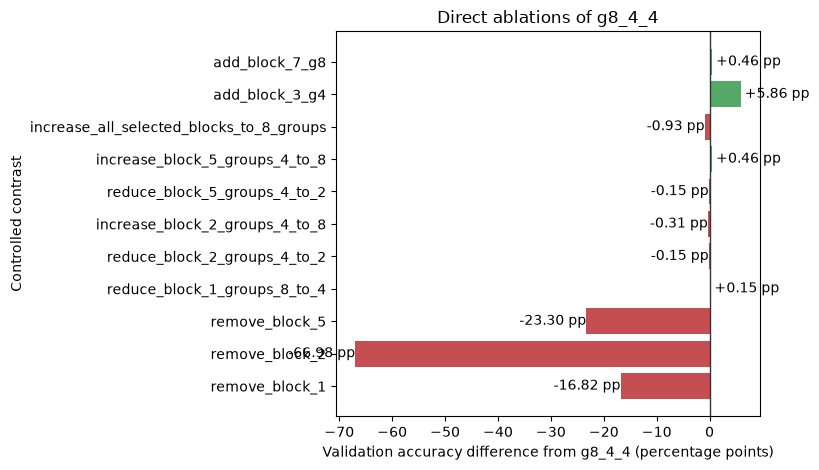

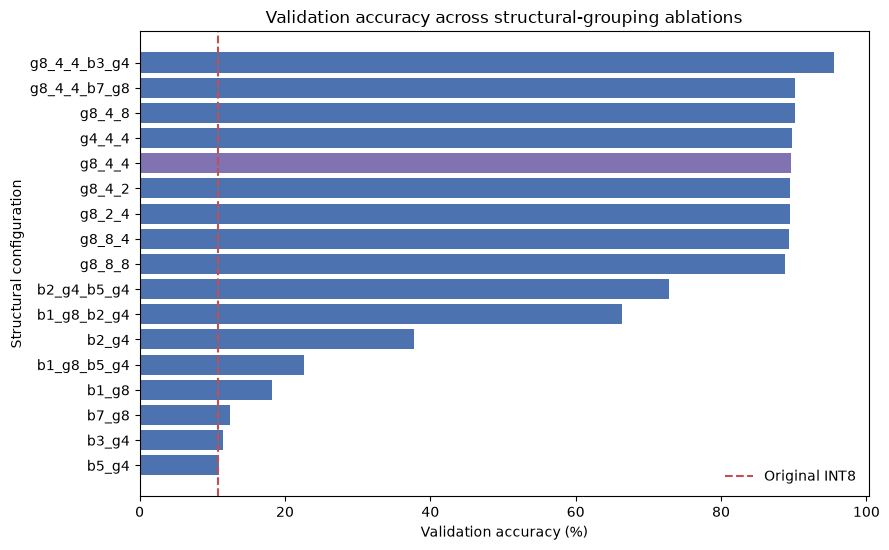

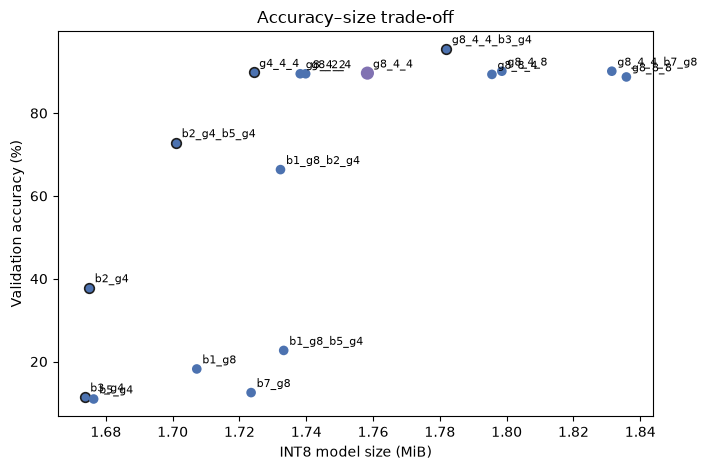

In [22]:
best_validation_accuracy = eligible_results["validation_int8_accuracy"].max()
VALIDATION_TOLERANCE = 1.0 / len(val_dataset)
near_best = eligible_results[
    eligible_results["validation_int8_accuracy"] >= best_validation_accuracy - VALIDATION_TOLERANCE
].copy()
near_best = near_best.sort_values(
    ["extra_branches", "size_bytes", "operator_count", "experiment"],
    ascending=[True, True, True, True],
)
selected_experiment = str(near_best.iloc[0]["experiment"])

def is_pareto_efficient(row, frame):
    dominates = (
        (frame["validation_int8_accuracy"] >= row["validation_int8_accuracy"])
        & (frame["size_bytes"] <= row["size_bytes"])
        & (
            (frame["validation_int8_accuracy"] > row["validation_int8_accuracy"])
            | (frame["size_bytes"] < row["size_bytes"])
        )
    )
    return not bool(dominates.any())

eligible_results["pareto_efficient"] = [
    is_pareto_efficient(row, eligible_results)
    for _, row in eligible_results.iterrows()
]
eligible_results["accuracy_delta_from_best"] = (
    eligible_results["validation_int8_accuracy"] - best_validation_accuracy
)
eligible_results = eligible_results.sort_values("validation_int8_accuracy", ascending=False)
target_row = eligible_results[eligible_results["experiment"] == TARGET_EXPERIMENT]
if target_row.empty:
    raise RuntimeError(f"Target experiment is not eligible: {TARGET_EXPERIMENT}")

target_validation_accuracy = float(target_row.iloc[0]["validation_int8_accuracy"])
eligible_results["accuracy_delta_from_target_pp"] = (
    eligible_results["validation_int8_accuracy"] - target_validation_accuracy
) * 100
eligible_results["correct_predictions_delta_from_target"] = np.rint(
    (eligible_results["validation_int8_accuracy"] - target_validation_accuracy) * len(val_dataset)
).astype(int)
eligible_results.to_csv(RESULTS_ROOT / "eligible_ablation_results.csv", index=False)

contrast_definitions = {
    "remove_block_1": "b2_g4_b5_g4",
    "remove_block_2": "b1_g8_b5_g4",
    "remove_block_5": "b1_g8_b2_g4",
    "reduce_block_1_groups_8_to_4": "g4_4_4",
    "reduce_block_2_groups_4_to_2": "g8_2_4",
    "increase_block_2_groups_4_to_8": "g8_8_4",
    "reduce_block_5_groups_4_to_2": "g8_4_2",
    "increase_block_5_groups_4_to_8": "g8_4_8",
    "increase_all_selected_blocks_to_8_groups": "g8_8_8",
    "add_block_3_g4": "g8_4_4_b3_g4",
    "add_block_7_g8": "g8_4_4_b7_g8",
}
contrast_rows = []
for contrast, comparison_name in contrast_definitions.items():
    comparison = eligible_results[eligible_results["experiment"] == comparison_name]
    if comparison.empty:
        continue
    comparison_accuracy = float(comparison.iloc[0]["validation_int8_accuracy"])
    contrast_rows.append({
        "contrast": contrast,
        "reference": TARGET_EXPERIMENT,
        "comparison": comparison_name,
        "reference_accuracy": target_validation_accuracy,
        "comparison_accuracy": comparison_accuracy,
        "comparison_minus_g8_4_4_pp": (comparison_accuracy - target_validation_accuracy) * 100,
        "correct_predictions_delta": int(round((comparison_accuracy - target_validation_accuracy) * len(val_dataset))),
    })
contrasts = pd.DataFrame(contrast_rows)
contrasts.to_csv(RESULTS_ROOT / "g8_4_4_contrasts.csv", index=False)
target_rank = int(eligible_results.reset_index(drop=True).index[eligible_results.reset_index(drop=True)["experiment"] == TARGET_EXPERIMENT][0]) + 1

selection = {
    "selected_experiment": selected_experiment,
    "target_experiment": TARGET_EXPERIMENT,
    "best_validation_accuracy": float(best_validation_accuracy),
    "validation_tolerance": float(VALIDATION_TOLERANCE),
    "selection_rule": "Within one validation sample of best accuracy, then minimum extra branches, size, and operators",
    "target_validation_accuracy": target_validation_accuracy,
    "target_validation_rank": target_rank,
    "target_delta_from_best": float(target_row.iloc[0]["accuracy_delta_from_best"]),
    "target_pareto_efficient": bool(target_row.iloc[0]["pareto_efficient"]),
}
with (RESULTS_ROOT / "selection.json").open("w") as file:
    json.dump(selection, file, indent=2)

print(json.dumps(selection, indent=2))
display(eligible_results)
display(contrasts)

if not contrasts.empty:
    figure, axis = plt.subplots(figsize=(8.2, 4.8))
    contrast_colors = ["#55A868" if value > 0 else "#C44E52" for value in contrasts["comparison_minus_g8_4_4_pp"]]
    bars = axis.barh(contrasts["contrast"], contrasts["comparison_minus_g8_4_4_pp"], color=contrast_colors)
    axis.axvline(0, color="#333333", linewidth=1)
    axis.set_xlabel("Validation accuracy difference from g8_4_4 (percentage points)")
    axis.set_ylabel("Controlled contrast")
    axis.set_title("Direct ablations of g8_4_4")
    for bar, value in zip(bars, contrasts["comparison_minus_g8_4_4_pp"]):
        axis.text(value, bar.get_y() + bar.get_height() / 2, f" {value:+.2f} pp", va="center", ha="left" if value >= 0 else "right")
    figure.tight_layout()
    figure.savefig(FIGURES_DIR / "g8_4_4_controlled_contrasts.png", dpi=300, bbox_inches="tight")
    figure.savefig(FIGURES_DIR / "g8_4_4_controlled_contrasts.pdf", bbox_inches="tight")
    plt.show()
    plt.close(figure)

plot_results = eligible_results.sort_values("validation_int8_accuracy")
figure, axis = plt.subplots(figsize=(9, 5.6))
colors = ["#8172B2" if name == TARGET_EXPERIMENT else "#4C72B0" for name in plot_results["experiment"]]
axis.barh(plot_results["experiment"], plot_results["validation_int8_accuracy"] * 100, color=colors)
axis.axvline(original_int8_validation["accuracy"] * 100, color="#C44E52", linestyle="--", label="Original INT8")
axis.set_xlabel("Validation accuracy (%)")
axis.set_ylabel("Structural configuration")
axis.set_title("Validation accuracy across structural-grouping ablations")
axis.legend(frameon=False)
figure.tight_layout()
figure.savefig(FIGURES_DIR / "ablation_validation_accuracy.png", dpi=300, bbox_inches="tight")
figure.savefig(FIGURES_DIR / "ablation_validation_accuracy.pdf", bbox_inches="tight")
plt.show()
plt.close(figure)

figure, axis = plt.subplots(figsize=(7.2, 4.8))
for _, row in eligible_results.iterrows():
    target = row["experiment"] == TARGET_EXPERIMENT
    axis.scatter(
        row["size_bytes"] / 1024 / 1024,
        row["validation_int8_accuracy"] * 100,
        s=90 if target else 48,
        color="#8172B2" if target else "#4C72B0",
        edgecolor="#1F1F1F" if row["pareto_efficient"] else "none",
        linewidth=1.2,
    )
    axis.annotate(row["experiment"], (row["size_bytes"] / 1024 / 1024, row["validation_int8_accuracy"] * 100), xytext=(4, 4), textcoords="offset points", fontsize=8)
axis.set_xlabel("INT8 model size (MiB)")
axis.set_ylabel("Validation accuracy (%)")
axis.set_title("Accuracy–size trade-off")
figure.tight_layout()
figure.savefig(FIGURES_DIR / "ablation_accuracy_size_tradeoff.png", dpi=300, bbox_inches="tight")
figure.savefig(FIGURES_DIR / "ablation_accuracy_size_tradeoff.pdf", bbox_inches="tight")
plt.show()
plt.close(figure)

## Avaliação final da configuração selecionada

In [23]:
selected_dir = VARIANTS_DIR / selected_experiment
selected_fp32_path = selected_dir / f"mobilevit_{selected_experiment}_fp32.tflite"
selected_int8_path = selected_dir / f"mobilevit_{selected_experiment}_int8.tflite"
selected_validation_accuracy = float(
    eligible_results.loc[
        eligible_results["experiment"] == selected_experiment,
        "validation_int8_accuracy",
    ].iloc[0]
)
validation_gain = selected_validation_accuracy - original_int8_validation["accuracy"]
test_gate_passed = (
    selected_validation_accuracy >= MIN_GROUPED_INT8_ACCURACY
    and validation_gain >= MIN_ACCURACY_GAIN
)

In [24]:
reference_metrics, reference_targets, reference_predictions = evaluate_tflite(
    selected_int8_path,
    val_loader,
    OpResolverType.BUILTIN_REF,
)
builtin_metrics, builtin_targets, builtin_predictions = evaluate_tflite(
    selected_int8_path,
    val_loader,
)

In [25]:
if not test_gate_passed:
    raise RuntimeError("Selected configuration failed the validation gate")

if not np.array_equal(reference_targets, builtin_targets):
    raise RuntimeError("Resolver reference changed validation targets")

if resolver_accuracy_delta > MAX_RESOLVER_ACCURACY_DELTA:
    raise RuntimeError(f"Resolver accuracy delta: {resolver_accuracy_delta:.6f}")
if np.unique(reference_predictions).size == 1:
    raise RuntimeError("Reference resolver produced constant predictions")

NameError: name 'resolver_accuracy_delta' is not defined

In [26]:
resolver_accuracy_delta = abs(reference_metrics["accuracy"] - builtin_metrics["accuracy"])
resolver_agreement = float(np.mean(reference_predictions == builtin_predictions))

test_models = {
    "original_fp32": ORIGINAL_FP32_PATH,
    "original_int8": ORIGINAL_INT8_PATH,
    "selected_fp32": selected_fp32_path,
    "selected_int8": selected_int8_path,
}
test_rows = []
selected_test_targets = None
selected_test_predictions = None
for model_name, model_path in test_models.items():
    metrics, targets, predictions = evaluate_tflite(model_path, test_loader)
    test_rows.append({"model": model_name, "split": "test", **metrics})
    if model_name == "selected_int8":
        selected_test_targets = targets
        selected_test_predictions = predictions
    print(model_name, metrics)

pd.DataFrame(test_rows).to_csv(RESULTS_ROOT / "selected_test_results.csv", index=False)
report = classification_report(
    selected_test_targets,
    selected_test_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0,
    output_dict=True,
)
with (RESULTS_ROOT / "selected_int8_test_report.json").open("w") as file:
    json.dump(report, file, indent=2)
np.savetxt(
    RESULTS_ROOT / "selected_int8_test_confusion_matrix.csv",
    confusion_matrix(selected_test_targets, selected_test_predictions, labels=range(len(class_names))),
    delimiter=",",
    fmt="%d",
)

final_summary = {
    **selection,
    "validation_gain_over_original_int8": validation_gain,
    "resolver_accuracy_delta": resolver_accuracy_delta,
    "resolver_prediction_agreement": resolver_agreement,
    "test_gate_passed": test_gate_passed,
}
with (RESULTS_ROOT / "final_summary.json").open("w") as file:
    json.dump(final_summary, file, indent=2)
print(json.dumps(final_summary, indent=2))

/opt/conda/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


original_fp32 {'accuracy': 0.9737654320987654, 'macro_precision': 0.9741657440318537, 'macro_recall': 0.9749186820859423, 'macro_f1': 0.9738519411097102, 'weighted_f1': 0.9737926072779836}
original_int8 {'accuracy': 0.10648148148148148, 'macro_precision': 0.21874577618763666, 'macro_recall': 0.10814184789856267, 'macro_f1': 0.05975190414506484, 'weighted_f1': 0.06133172509202985}
selected_fp32 {'accuracy': 0.9737654320987654, 'macro_precision': 0.9741657440318537, 'macro_recall': 0.9749186820859423, 'macro_f1': 0.9738519411097102, 'weighted_f1': 0.9737926072779836}
selected_int8 {'accuracy': 0.9629629629629629, 'macro_precision': 0.96416696104822, 'macro_recall': 0.9628385311400723, 'macro_f1': 0.9628216007888424, 'weighted_f1': 0.9629312130020155}
{
  "selected_experiment": "g8_4_4_b3_g4",
  "target_experiment": "g8_4_4",
  "best_validation_accuracy": 0.9552469135802469,
  "validation_tolerance": 0.0015432098765432098,
  "selection_rule": "Within one validation sample of best accuracy

## Interpretação

O argumento em favor de `g8_4_4` somente será sustentado se os resultados mostrarem simultaneamente:

1. ganho substancial sobre o INT8 original;
2. contribuição dos blocos 1, 2 e 5 nos testes isolados e de remoção;
3. ausência de benefício consistente ao acrescentar os blocos 3 ou 7;
4. posição competitiva na fronteira entre acurácia e custo estrutural;
5. equivalência FP32 dentro dos limites declarados;
6. compatibilidade integral INT8 e concordância entre resolvers.

Se outra configuração vencer segundo a regra pré-declarada, o resultado deve ser reportado como evidência contra a escolha inicial, sem usar o conjunto de teste para redefinir a configuração.

Como o conjunto de teste já foi consultado nos experimentos v2 e v3, esta execução não restaura um teste completamente cego. Para uma confirmação independente, deve-se reservar um novo conjunto final ou repetir a comparação por validação cruzada, mantendo qualquer novo teste oculto até o congelamento da configuração.